## Overview

for different models

predict data of one test season, but training was different

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 7.6.

In [2]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

from matplotlib.lines import Line2D
import xarray as xr

from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [3]:
#working_dir=" "#"../../../datasets/small_grid"
image_folder="images"
dataloader_dir="../../../datasets/small_grid/dataloaders"

#!cd {working_dir} && ls
#print("\n")
!cd {image_folder} && ls
print("\n")
!cd {dataloader_dir} && ls

 10u_over_training_timeframe_overlayed_by_year.png
 10v_over_training_timeframe_overlayed_by_year.png
 2t_over_training_timeframe_colored.png
 2t_over_training_timeframe_overlayed_by_year.png
 2t_over_training_timeframe.png
 2t_over_training_timeframe_with_train_test_indices.png
'ChatGPT Image 29. Mai 2026, 22_01_53.png'
 GRU_losses_combined_plots.png
 losses_vs_epochs_combined+LSTM-HPT.png
 losses_vs_epochs_combined.png
 losses_vs_epochs_past.png
 losses_vs_epochs_recent+LSTM-HPT.png
 losses_vs_epochs_recent.png
 LSTM_losses_combined_plots.png
 LSTM_true_vs_pred_same_season.png
 sp_over_training_timeframe_overlayed_by_year.png
 ssrd_over_training_timeframe_overlayed_by_year.png
 tcc_over_training_timeframe_overlayed_by_year.png
 tcc_over_training_timeframe_with_train_test_indices.png
 tp_over_training_timeframe_overlayed_by_year.png


now_autumn_dataloader_test.pt	   recent_autumn_scaler_set.pt
now_skipped_idx_test.csv	   recent_autumn_scaler_y.pt
now_spring_dataloader_test.pt	   rece

## Loading test_dataloaders

In [4]:
dataloaderlist = [p.name for p in Path(dataloader_dir).iterdir() if p.is_file()]
dataloaderlist = [f for f in dataloaderlist if f.endswith('.pt')]
dataloaderlist=[f for f in dataloaderlist if "dataloader" in f]      #select only the ones with "dataloader" in the name
dataloaderlist=[f for f in dataloaderlist if "now" in f]
dataloaderlist

['now_autumn_dataloader_test.pt',
 'now_winter_dataloader_test.pt',
 'now_summer_dataloader_test.pt',
 'now_spring_dataloader_test.pt']

In [5]:
test_dataloader = {}
i=0
for dl in dataloaderlist:
    season = dl.split("_")[1]
    print(season)
    path = dataloader_dir + "/" + dl
    #print(path)
    test_dataloader[season] = torch.load(path, weights_only=False)
    i=i+1
print(i,"Dataloaders loaded successfully.")

autumn
winter
summer
spring
4 Dataloaders loaded successfully.


## Loading models

In [6]:
time={"recent": "2015-2024"}
selected_model="GRU" #select the model to load the checkpoints for


model_dir="models/"+selected_model #get the model name from the selected_model variable

modellist = [p.name for p in Path(model_dir).iterdir() if p.is_file()]
modellist = [f for f in modellist if f.endswith('.pth')]
#select only models with "recent" in the name
modellist = [f for f in modellist if time.keys().__iter__().__next__() in f]
modellist.sort()
print(modellist)

['cnn_gru_recent_autumn.pth', 'cnn_gru_recent_spring.pth', 'cnn_gru_recent_summer.pth', 'cnn_gru_recent_winter.pth']


In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model_checkpoint = {}
i=0
for m in modellist:
    season = m.split("_")[-1]
    season = season.split(".")[0]
    print(season)
    path = model_dir + "/" + m
    #print(path)
    model_checkpoint[season] = torch.load(path,map_location=device)
    i=i+1
print(i,"Models loaded successfully.")

Using cpu device
autumn
spring
summer


winter
4 Models loaded successfully.


In [8]:
class CNN_GRU(nn.Module):
    def __init__(self,in_channels=7,hidden_size=16,lat_size=5,lon_size=5):
        super().__init__()

        #compressing space
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.conv1 = double_conv(in_channels, 16)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = double_conv(16, 32)

        #compressing time
        self.gru = nn.GRU(input_size=32,hidden_size=32*25, num_layers=1,dropout=0.2,batch_first=True)
        
        #expanding space
        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=3, padding=1)


    def forward(self, x):
        #print("starting forward:",x.shape)
        x_gru=[]
        #recognize patterns of the spatial data with CNN
        for time in range(x.shape[1]):
            #print(time)
            cnn_in=x[:, time, :, :]
            #print("time,cnn_in.shape:",time,cnn_in.shape)
            cnn_in=self.conv1(cnn_in)
            #print("after conv1:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = self.conv2(cnn_in)
            #print("after conv2:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = cnn_in.view(cnn_in.size(0), -1)  # Flatten for GRU input
            #print("after flatten:",cnn_in.shape)
            x_gru.append(cnn_in)
        x_gru = torch.stack(x_gru, dim=1)
        #print("shaped for GRU:",x_gru.shape)#(batch, time, convoluted features with space)

        #decoding the temporal patterns with GRU
        x,_ = self.gru(x_gru)#x:(batch, time, hidden_size)
        x = x[:,-1,:].view(x.shape[0],32,5,5)##(batch, last hidden_size,lat_size,lon_size)
        #print("after GRU:",x.shape)
        x=self.deconv1(x)
        #print("after deconv1:",x.shape)
        x=self.deconv2(x)
        #print("after deconv2:",x.shape)
        return x#

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=7, hidden_size=16, lat_size=5, lon_size=5):
        super().__init__()

        self.lat_size = lat_size
        self.lon_size = lon_size
        self.feature_channels = 32

        # Compressing space
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
            )

        self.conv1 = double_conv(in_channels, 16)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = double_conv(16, self.feature_channels)

        # Force spatial size so lat_size/lon_size are used consistently
        self.spatial_pool = nn.AdaptiveAvgPool2d((lat_size, lon_size))

        # Compressing time with LSTM
        self.seq_input_size = self.feature_channels * lat_size * lon_size
        self.hidden_size = hidden_size if hidden_size is not None else self.seq_input_size

        self.lstm = nn.LSTM(
            input_size=self.seq_input_size,
            hidden_size=self.hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Map LSTM hidden state back to spatial tensor size
        self.proj = nn.Linear(self.hidden_size, self.seq_input_size)

        # Expanding space
        self.deconv1 = nn.ConvTranspose2d(self.feature_channels, 16, kernel_size=3, padding=1)
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x_seq = []
        for t in range(x.shape[1]):
            cnn_in = x[:, t, :, :]
            cnn_in = self.conv1(cnn_in)
            cnn_in = self.maxpool(cnn_in)
            cnn_in = self.conv2(cnn_in)
            cnn_in = self.maxpool(cnn_in)
            cnn_in = self.spatial_pool(cnn_in)
            cnn_in = cnn_in.view(cnn_in.size(0), -1)  # (batch, seq_input_size)
            x_seq.append(cnn_in)

        x_seq = torch.stack(x_seq, dim=1)  # (batch, time, seq_input_size)

        # LSTM over time
        x, _ = self.lstm(x_seq)
        x = x[:, -1, :]                    # last timestep
        x = self.proj(x)                   # (batch, seq_input_size)
        x = x.view(x.size(0), self.feature_channels, self.lat_size, self.lon_size)

        x = self.deconv1(x)
        x = self.deconv2(x)
        return x


def test(dataloader, model, loss_fn,device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            test_loss += loss_fn(predictions, y).item()

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    test_loss /= num_batches
    y_pred = np.concatenate(all_predictions)#[:,:,0]
    y_true = np.concatenate(all_targets)#[:,:,0]
    #print(f"y_true shape: {y_true.shape}, y_pred shape: {y_pred.shape}")

    # Flatten everything to 2D: (samples, features)
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    #mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    #rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true_flat, y_pred_flat)
    print(f"Test Error:\n R2: {r2:>8f}, Avg loss: {test_loss:>8f} \n")
    return test_loss

## Calculate losses for all combinations of training and prediction seasons

In [10]:
loss_fcn = nn.MSELoss()

training_seasons = {
    "spring": "tab:green",
    "summer": "tab:orange",
    "autumn": "tab:purple",
    "winter": "tab: brown"}
prediction_seasons={
    "spring": "MAM",
    "summer": "JJA",
    "autumn": "SON",
    "winter": "DJF"}

losses = {}
only_same_season = True #if True, only test the model on the same season it was trained on, if False, test on all seasons

#if model losses are already calculated, load them from csv file
loss_csv_path = f"{selected_model}_losses_on_wrong_training_seasons.csv"
if os.path.exists(loss_csv_path):
    print(f"Loading losses from {loss_csv_path}...")
    loss_df = pd.read_csv(loss_csv_path, index_col=0)
    losses = loss_df.to_dict(orient='index')
    print("Losses loaded successfully.")
else:
    for tr_season in training_seasons.keys():
        #print(f"Testing model trained on {tr_season} data...")
        losses[tr_season] = {}

        for pred_season in prediction_seasons.keys():
            if only_same_season and tr_season != pred_season:
                print(f"Skipping {tr_season}→{pred_season} (same season)")
                losses[tr_season][pred_season] = None
                continue
            if selected_model == "GRU":
                loaded_model = CNN_GRU().to(device)
            elif selected_model == "LSTM":
                loaded_model = CNN_LSTM().to(device)
            else:
                raise ValueError(f"Unknown model type: {selected_model}")
            #print(model_checkpoint[season].keys())
            loaded_model.load_state_dict(model_checkpoint[tr_season]["model_state_dict"])
            loaded_epoch = model_checkpoint[tr_season]["epoch"]
            #print(f"Modeltraining stopped at epoch: {loaded_epoch}")  
            loaded_model.eval() # Set model to evaluation mode for inference

            #print(f"  Predicting for {pred_season} season...")
            loss = test(test_dataloader[pred_season], loaded_model, loss_fcn, device)
            print(f"Loss for model trained on {tr_season} and tested on {pred_season}: {loss:.4f}")
            losses[tr_season][pred_season] = loss
            print("-"*30,"\n")

print("Done!")

/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Test Error:
 R2: 0.760952, Avg loss: 0.252081 

Loss for model trained on spring and tested on spring: 0.2521
------------------------------ 

Skipping spring→summer (same season)
Skipping spring→autumn (same season)
Skipping spring→winter (same season)
Skipping summer→spring (same season)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Test Error:
 R2: 0.721676, Avg loss: 0.290958 

Loss for model trained on summer and tested on summer: 0.2910
------------------------------ 

Skipping summer→autumn (same season)
Skipping summer→winter (same season)
Skipping autumn→spring (same season)
Skipping autumn→summer (same season)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Test Error:
 R2: 0.827686, Avg loss: 0.168021 

Loss for model trained on autumn and tested on autumn: 0.1680
------------------------------ 

Skipping autumn→winter (same season)
Skipping winter→spring (same season)
Skipping winter→summer (same season)
Skipping winter→autumn (same season)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Test Error:
 R2: 0.875946, Avg loss: 0.120174 

Loss for model trained on winter and tested on winter: 0.1202
------------------------------ 

Done!


In [29]:
for tr_season, pred_seasons in losses.items():
    print(f"Model trained on {tr_season} season:")
    for pred_season, loss in pred_seasons.items():
        print(f"  Loss when predicting {pred_season} season: {loss:.4f}")
    print("-"*30)

#save the losses for later use in a csv file via pd.DataFrame
loss_df = pd.DataFrame(losses)
loss_df.to_csv(f"{selected_model}_losses_on_wrong_training_seasons.csv")

Model trained on spring season:
  Loss when predicting spring season: 0.2521


TypeError: unsupported format string passed to NoneType.__format__

## plot results in a matrix plot and in a bar plot


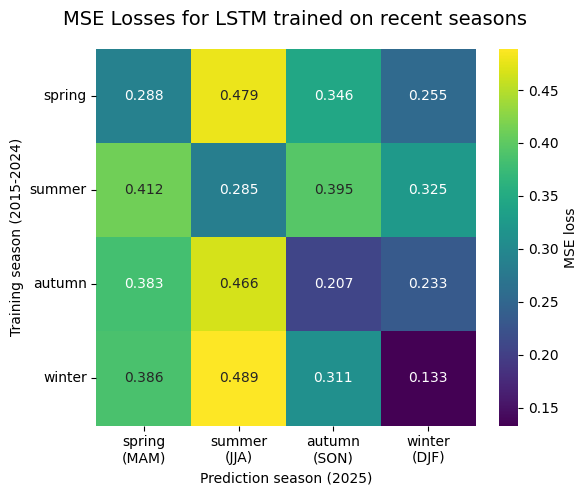

In [10]:
# prepare dataframe with training seasons as rows and prediction seasons as columns
df = pd.DataFrame(losses).T
train_order = list(training_seasons.keys())
pred_order = list(prediction_seasons.keys())
df = df.reindex(index=train_order, columns=pred_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar_kws={'label': 'MSE loss'})

# axis labels and tick labels (use abbrev for x ticks)
ax.set_xlabel("Prediction season (2025)")
ax.set_ylabel(f"Training season ({time['recent']})")
ax.set_xticklabels([f"{p}\n({prediction_seasons[p]})" for p in pred_order], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle(f"MSE Losses for {selected_model} trained on recent seasons", fontsize=14)
# color y tick labels according to training_seasons colors (clean spaces)
for txt, season in zip(ax.get_yticklabels(), train_order):
    color = training_seasons.get(season, None)
    if isinstance(color, str):
        color = color.replace(" ", "")
#    txt.set_color(color)

plt.tight_layout()
if False:
    plt.savefig(f"{image_folder}/{selected_model}_loss_matrix.png", dpi=300)
plt.show()

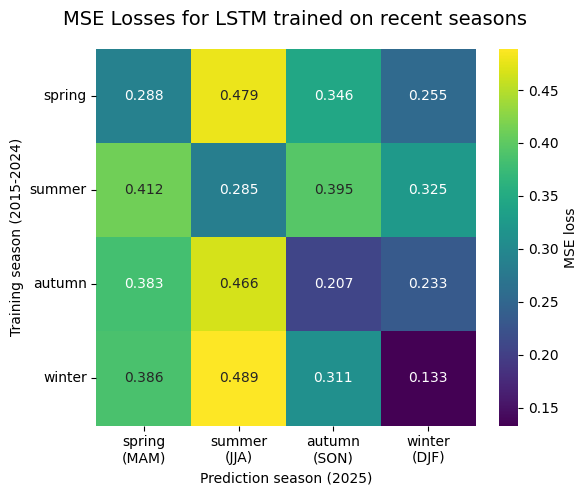

In [11]:
# prepare dataframe with training seasons as rows and prediction seasons as columns
df = pd.DataFrame(losses).T
train_order = list(training_seasons.keys())
pred_order = list(prediction_seasons.keys())
df = df.reindex(index=train_order, columns=pred_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar_kws={'label': 'MSE loss'})

# axis labels and tick labels (use abbrev for x ticks)
ax.set_xlabel("Prediction season (2025)")
ax.set_ylabel(f"Training season ({time['recent']})")
ax.set_xticklabels([f"{p}\n({prediction_seasons[p]})" for p in pred_order], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.suptitle(f"MSE Losses for {selected_model} trained on recent seasons", fontsize=14)
# color y tick labels according to training_seasons colors (clean spaces)
for txt, season in zip(ax.get_yticklabels(), train_order):
    color = training_seasons.get(season, None)
    if isinstance(color, str):
        color = color.replace(" ", "")
#    txt.set_color(color)

plt.tight_layout()
if False:
    plt.savefig(f"{image_folder}/{selected_model}_loss_matrix.png", dpi=300)
plt.show()

## plot results 

generate a bar plot with the prediction seasons on the x axis and test losses on the y axes. per season there are 4 models represented, which should be represented in bars in the color defined by the training season dict.

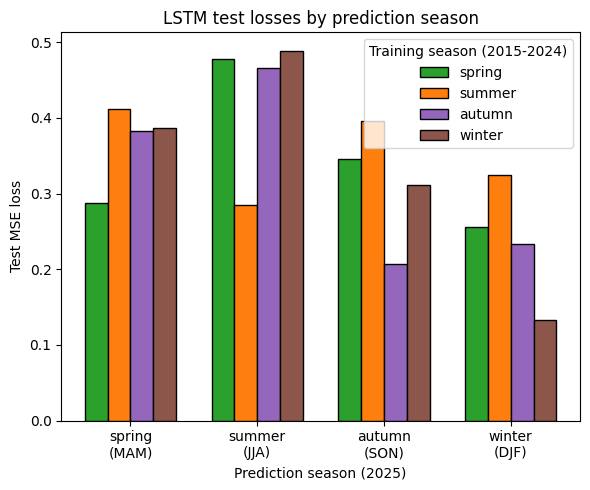

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

n_pred = len(pred_order)
n_train = len(train_order)
bar_width = 0.18
x = np.arange(n_pred)

for i, tr in enumerate(train_order):
    vals = df.loc[tr, pred_order].values
    positions = x - (n_train-1)/2*bar_width + i*bar_width
    color = training_seasons.get(tr, None)
    if isinstance(color, str):
        color = color.replace(" ", "")
    ax.bar(positions, vals, width=bar_width, label=tr, color=color, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({prediction_seasons[p]})" for p in pred_order], rotation=0)
ax.set_xlabel("Prediction season (2025)")
ax.set_ylabel("Test MSE loss")
ax.set_title(f"{selected_model} test losses by prediction season")
ax.legend(title="Training season (2015-2024)")
plt.tight_layout()

if False:
    plt.savefig(f"{image_folder}/{selected_model}_losses_barplot.png", dpi=300)

plt.show()

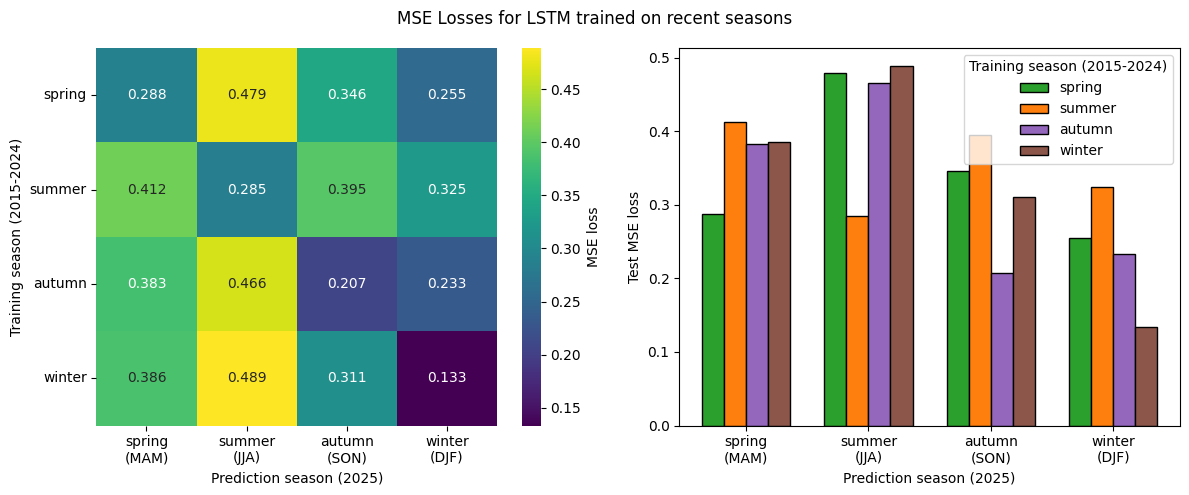

In [ ]:
fig, axs = plt.subplots(1, 2 , figsize=(12, 5))


fig.suptitle(f"MSE Losses for {selected_model} trained on recent seasons")

# left: heatmap (matrix)
ax0 = axs[0]
sns.heatmap(df.reindex(index=train_order, columns=pred_order), annot=True, fmt=".3f",
            cmap="viridis", ax=ax0, cbar_kws={'label': 'MSE loss'})
ax0.set_xlabel("Prediction season (2025)")
ax0.set_ylabel(f"Training season ({time['recent']})")
ax0.set_xticklabels([f"{p}\n({prediction_seasons[p]})" for p in pred_order], rotation=0)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

# right: grouped bar plot
ax1 = axs[1]
n_pred = len(pred_order)
n_train = len(train_order)
x = np.arange(n_pred)

for i, tr in enumerate(train_order):
    vals = df.loc[tr, pred_order].values
    positions = x - (n_train - 1) / 2 * bar_width + i * bar_width
    color = training_seasons.get(tr, None)
    if isinstance(color, str):
        color = color.replace(" ", "")
    ax1.bar(positions, vals, width=bar_width, label=tr, color=color, edgecolor='black')

ax1.set_xticks(x)
ax1.set_xticklabels([f"{p}\n({prediction_seasons[p]})" for p in pred_order], rotation=0)
ax1.set_xlabel("Prediction season (2025)")
ax1.set_ylabel("Test MSE loss")
ax1.legend(title="Training season (2015-2024)")

plt.tight_layout()
if False:
    plt.savefig(f"{image_folder}/{selected_model}_losses_combined_plots.png", dpi=300)
plt.show()

## making a regression plot for model



In [12]:
# regression scatter plots: model trained on each season vs same-season predictions
preds_by_season = {}
truths_by_season = {}


#train_order = list(training_seasons.keys())
#pred_order = list(prediction_seasons.keys())

# collect predictions & truths per season
for season in train_order:
    print(f"Collecting predictions for model trained on {season} season...")
    if selected_model == "GRU":
        mdl = CNN_GRU().to(device)
    elif selected_model == "LSTM":
        mdl = CNN_LSTM().to(device)
    else:
        raise ValueError(f"Unknown model type: {selected_model}")
    mdl.load_state_dict(model_checkpoint[season]["model_state_dict"])
    mdl.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for X, y in test_dataloader[season]:
            X, y = X.to(device), y.to(device)
            p = mdl(X)
            all_p.append(p.cpu().numpy().ravel())
            all_t.append(y.cpu().numpy().ravel())
    preds_by_season[season] = np.concatenate(all_p)
    truths_by_season[season] = np.concatenate(all_t)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


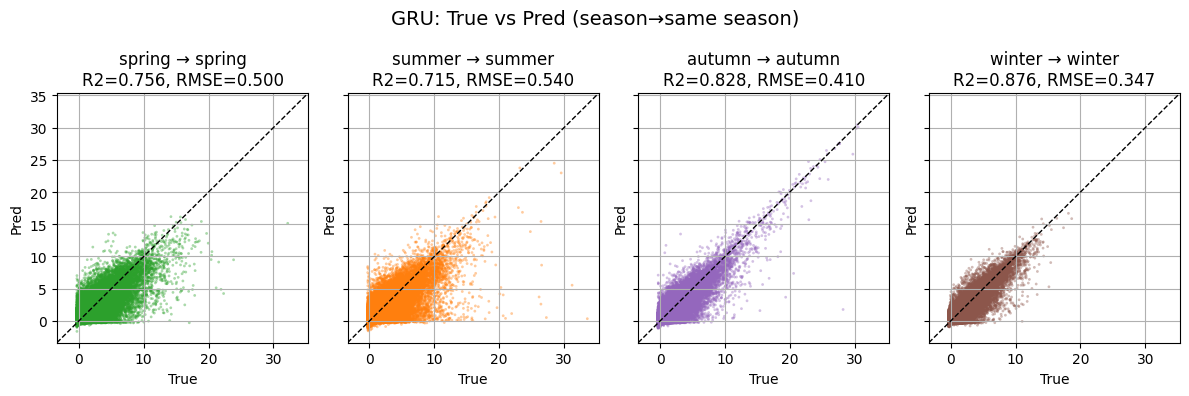

In [ ]:
# global axis limits
all_vals = np.concatenate([np.concatenate([truths_by_season[s], preds_by_season[s]]) for s in train_order])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
pad = 0.05 * (vmax - vmin) if vmax > vmin else 0.1
lims = (vmin - pad, vmax + pad)

fig, axs = plt.subplots(1, len(train_order), figsize=(12,4), sharex=True, sharey=True)

for ax, season in zip(axs, train_order):
    y_true = truths_by_season[season]
    y_pred = preds_by_season[season]
    color = training_seasons.get(season, None)
    if isinstance(color, str):
        color = color.replace(" ", "")
    ax.scatter(y_true, y_pred, s=4, alpha=0.4, color=color, edgecolor='none')
    ax.plot(lims, lims, 'k--', linewidth=1)
    r2 = sklearn.metrics.r2_score(y_true, y_pred)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    ax.set_title(f"{season} → {season}\nR2={r2:.3f}, RMSE={rmse:.3f}")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")
    ax.grid()

fig.suptitle(f"{selected_model}: True vs Pred (season→same season)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])
if False:
    fig.savefig(f"{image_folder}/{selected_model}_true_vs_pred_same_season.png", dpi=300)